In [2]:
# Convergence plotter
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.patches as patches
import matplotlib.colors as colors

savedir = '/home/kale-chen/Documents/PET/Sensitivity Normalization/writeup/plots/timecalconv'

mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)
map = mapdf.to_numpy()[:, 0:3]
# File containing geometric offsets table, can generate from map with geotabler.py
geo_offsets_dir = '/home/kale-chen/Documents/PET/MDA_03162026/Data/geometrictimeoffsets2.bin'

# Heatmap utils
heatmapmin, heatmapmax = -1000, 1000
def setheatmapminmax(min, max):
    global heatmapmin, heatmapmax
    heatmapmin, heatmapmax = min, max

cmap = plt.get_cmap('RdBu_r') # 'seismic' or 'RdBu' or 'rwb'
mapL = mapdf.iloc[3072:]
mapR = mapdf.iloc[:3072]
mapL = np.round(mapL, 2)
mapR = np.round(mapR, 2)
ycoordsL, countsL = np.unique(mapL.iloc[:, 1], return_counts=True)
zcoordsL, countsL = np.unique(mapL.iloc[:, 2], return_counts=True)
ycoordsR, countsR = np.unique(mapR.iloc[:, 1], return_counts=True)
ycoordsR = ycoordsR[::-1] # To keep view from isocenter outwards
zcoordsR, countsR = np.unique(mapR.iloc[:, 2], return_counts=True)
scanner_arc_L = np.zeros((32, 96))
scanner_arc_R = np.zeros((32, 96))
for i in range(3072):
    scanner_arc_R[np.where(zcoordsR == mapR.iloc[i, 2]), np.where(ycoordsR == mapR.iloc[i, 1])] = i
for i in range(3072):
    scanner_arc_L[np.where(zcoordsL == mapL.iloc[i, 2]), np.where(ycoordsL == mapL.iloc[i, 1])] = i+3072
def getcolor(value, cmap = 'RdBu_r', numdiscretecolors = 20):
    colormap = plt.get_cmap(cmap)
    if value < heatmapmin:
        return colormap(0.0)
    elif value > heatmapmax:
        return colormap(1.0)
    else:
        return colormap((value - heatmapmin) / (heatmapmax - heatmapmin) * (numdiscretecolors - 2) // 1 / (numdiscretecolors - 2))
def makeheatmap(countsIDorder,title, savename, heatmapmin = -1000, heatmapmax = 1000):
    setheatmapminmax(heatmapmin, heatmapmax)
    heatmapL = np.zeros((32, 96))
    heatmapR = np.zeros((32, 96))
    for i in range(3072):
        index = np.where(scanner_arc_R == i)
        heatmapR[index] = countsIDorder[i]
    for i in range(3072, 6144):
        index = np.where(scanner_arc_L == i)
        heatmapL[index] = countsIDorder[i]
    #Dead cells
    for i in range(32):
        for j in range(96):
            if heatmapR[i, j] == 0:
                heatmapR[i, j] = -1
            if heatmapL[i, j] == 0:
                heatmapL[i, j] = -1

    face_dim = 3.2
    space = 1.2
    blank_color = 'black'
        
    fig, ax = plt.subplots(figsize = (8, 6))

    #rect = patches.Rectangle((-2, -104.8), 324.4, 225.6, facecolor='black', alpha = 0.2)
    #ax.add_patch(rect)

    # Plot R
    for z in range(32):
        zspace = z // 8 * space
        for y in range(96):
            yspace = y // 8 * space
            if heatmapR[z, y] != -1:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=getcolor(heatmapR[z, y], cmap = cmap))
                ax = plt.gca()
                ax.add_patch(rect)
            else:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=blank_color)
                ax = plt.gca()
                ax.add_patch(rect)

    # Plot L
    for z in range(32):
        zspace = z // 8 * space 
        for y in range(96):
            yspace = y // 8 * space
            if heatmapL[z, y] != -1:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)+ 110), face_dim, face_dim, facecolor=getcolor(heatmapL[z, y], cmap = cmap))
                ax = plt.gca()
                ax.add_patch(rect)
            else:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace) + 110), face_dim, face_dim, facecolor=blank_color)
                ax = plt.gca()
                ax.add_patch(rect)
    bounds = np.linspace(heatmapmin, heatmapmax, 21)
    norm = colors.BoundaryNorm(bounds, cmap.N)
    mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
    diff = heatmapmax - heatmapmin
    cbar.set_ticks([heatmapmin, heatmapmin+diff*0.0, heatmapmin+diff*0.1, heatmapmin+diff*0.15, heatmapmin+diff*0.2, heatmapmin+diff*0.25, heatmapmin+diff*0.3, heatmapmin+diff*0.35, heatmapmin+diff*0.4, heatmapmin+diff*0.45, heatmapmin+diff*0.5, heatmapmin+diff*0.55, heatmapmin+diff*0.6, heatmapmin+diff*0.65, heatmapmin+diff*0.7, heatmapmin+diff*0.75, heatmapmin+diff*0.8, heatmapmin+diff*0.85, heatmapmin+diff*0.9, heatmapmin+diff*0.95, heatmapmax])
    cbar.set_ticklabels([
        '',
        #f'{heatmapmin:.2e}',
        f'{heatmapmin}',
        '', '', '', '', '', '', '', '',
        f'{heatmapmin+diff*0.5}',
        '', '', '', '', '', '', '', '', '',
        f'{heatmapmax}'
    ])
    plt.xlim(-2,322.4)
    pady = 36
    plt.ylim(-104.8 - pady, 113.2)
    plt.axis('off')
    #plt.tight_layout()
    plt.title(title)
    plt.savefig(os.path.join(savedir, f'{savename}heatmap.pdf'), format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

def makehist(eventcounts, eventcountsIDorder, title, savename, fit = True, heatmapmin = 0.75, heatmapmax = 1.25):
    plt.figure(1, figsize = (6, 3))
    bins = np.linspace(heatmapmin, heatmapmax, 200)
    plt.hist(eventcounts, bins = bins, color = 'red', label = 'Uncorrected', histtype = 'step', linewidth = 1)
    hist, bins = plt.hist(eventcountsIDorder, bins = bins, color = 'blue', label = 'Corrected', histtype = 'step', linewidth = 1)[0:2]
    def gaussian(x, a, mu, sigma):
        return a * np.exp(-(x - mu)**2 / (2 * sigma**2))
    if fit:
        bincenters = (bins[1:] + bins[:-1]) / 2
        popt, _ = curve_fit(gaussian, bincenters, hist, p0 = [100, 1.0, 0.03])
        print(popt)
        plotting_bounds = np.linspace(popt[1] - 4 * popt[2], popt[1] + 4 * popt[2], 100)
        plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'black', label = f'sigma = {np.abs(popt[2]):.4f}')
    plt.legend()
    plt.xlim(heatmapmin - 10, heatmapmax + 10)
    plt.xlabel('Time offset (ps)')
    plt.ylabel('Num channels')
    plt.title(title)
    plt.savefig(os.path.join(savedir, f'{savename}hist.pdf'), format='pdf', dpi=300, bbox_inches='tight')
    plt.show()


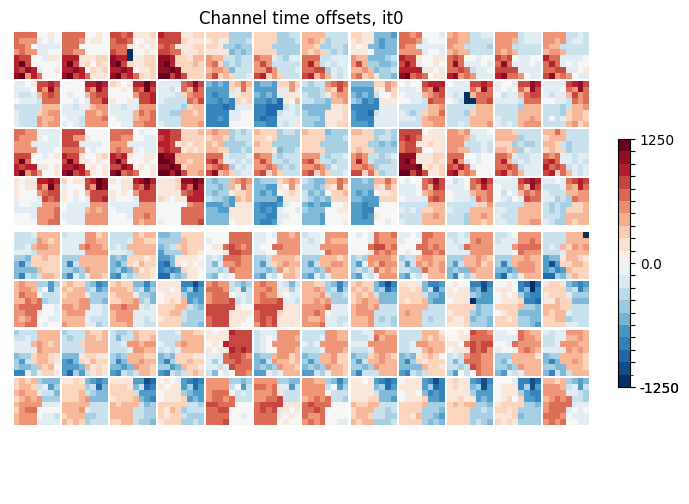

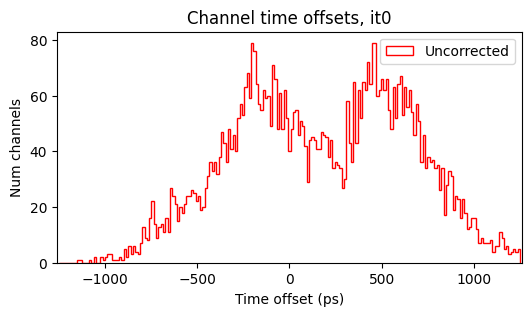

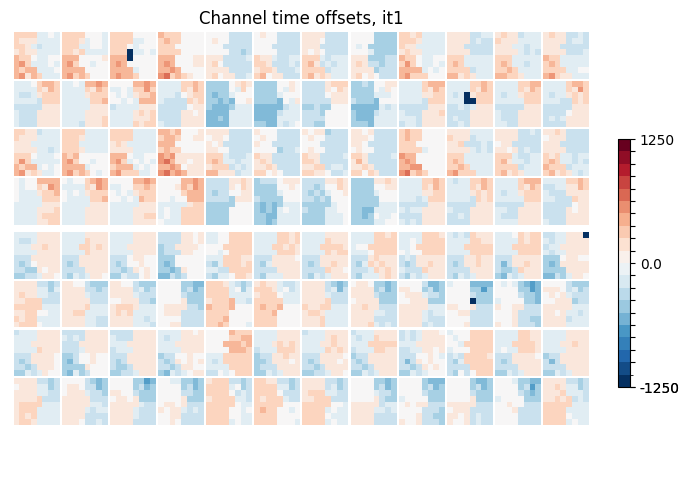

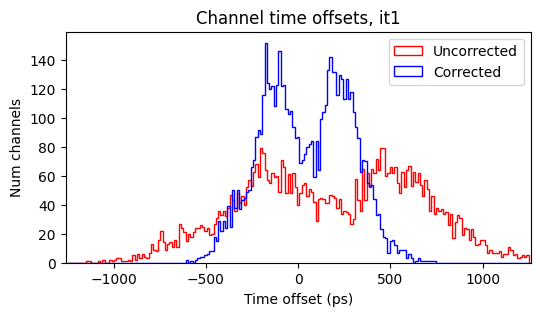

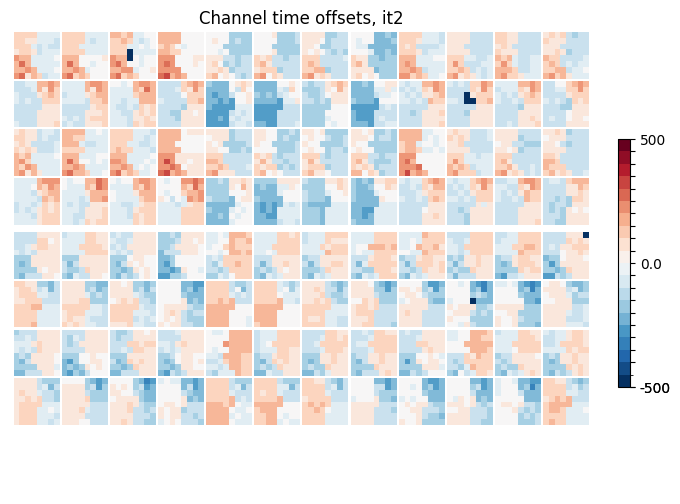

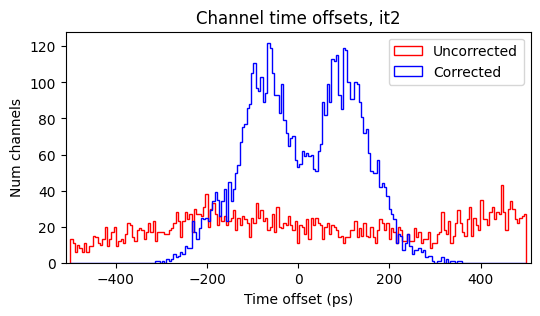

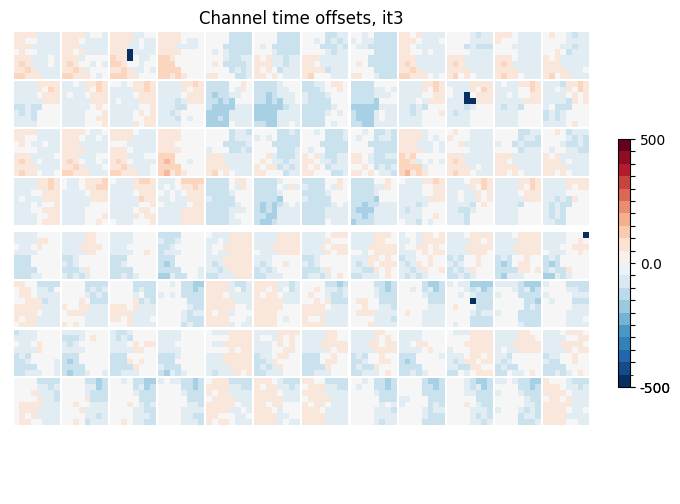

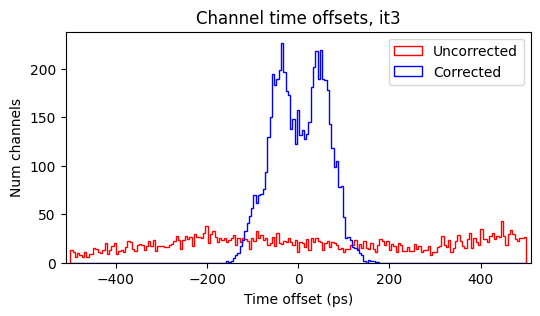

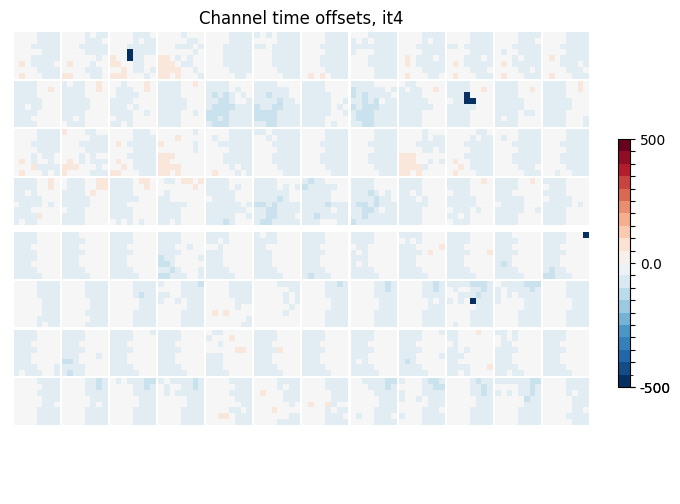

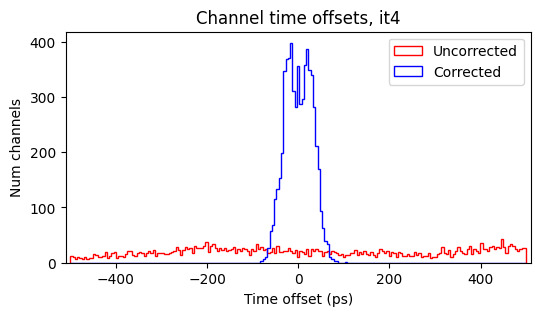

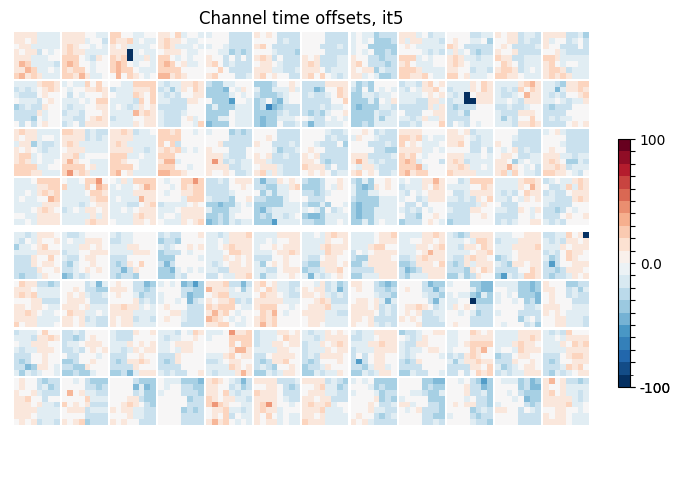

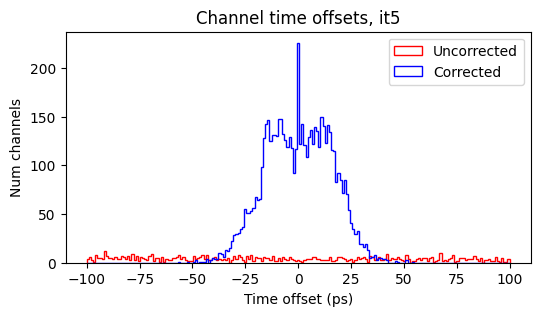

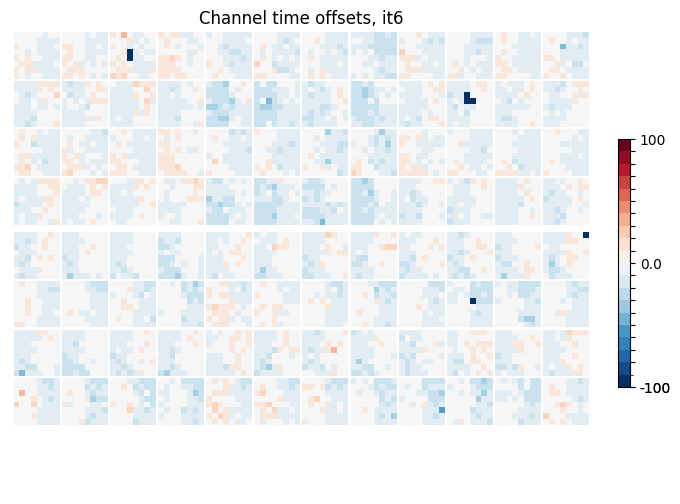

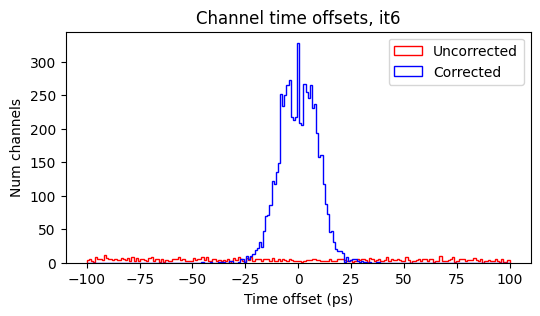

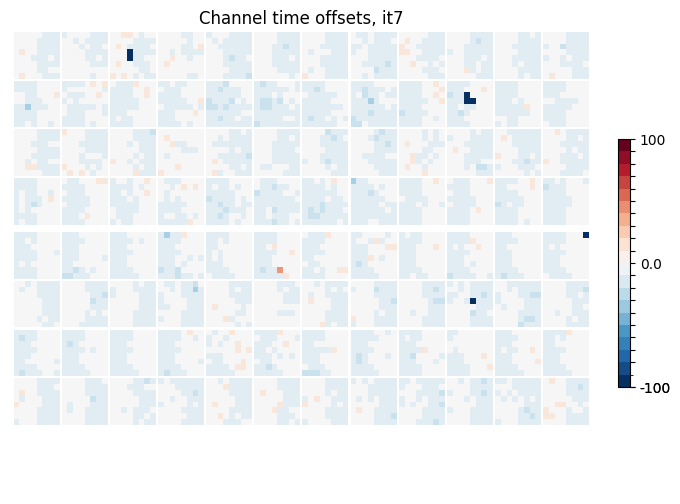

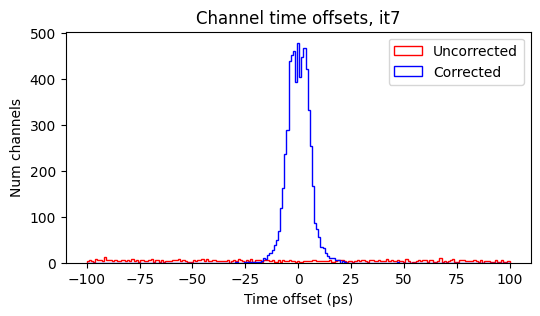

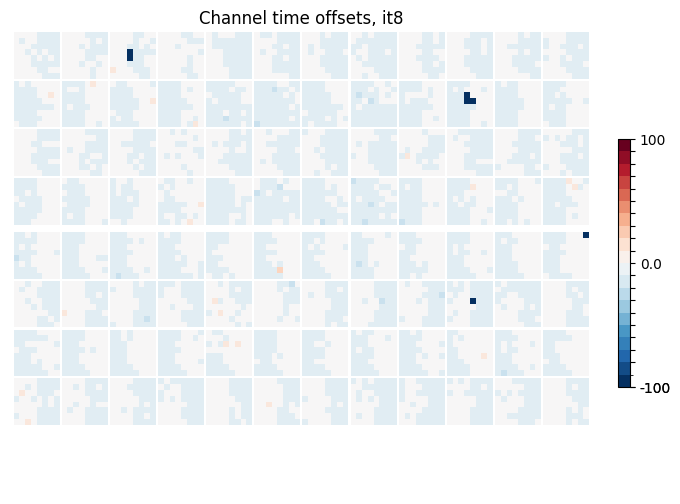

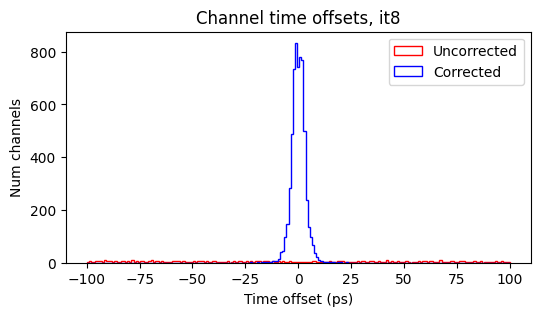

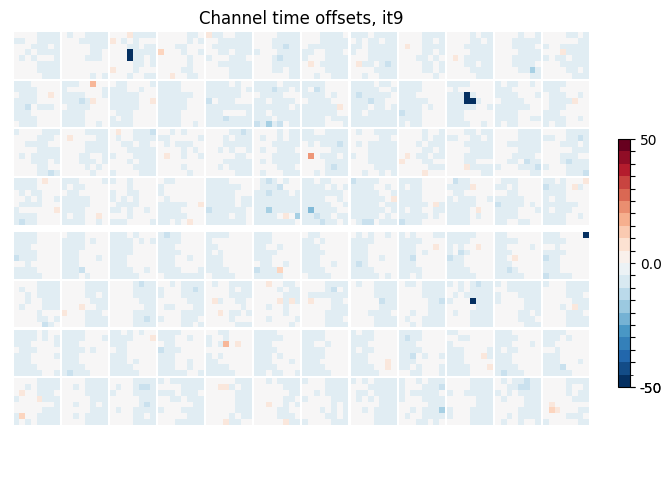

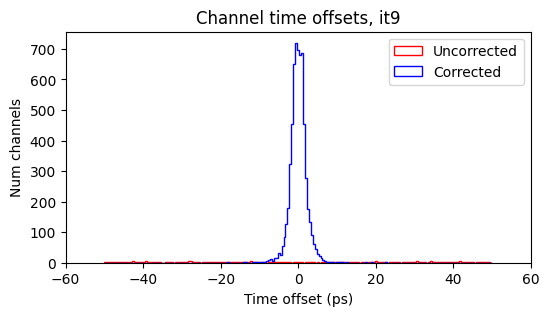

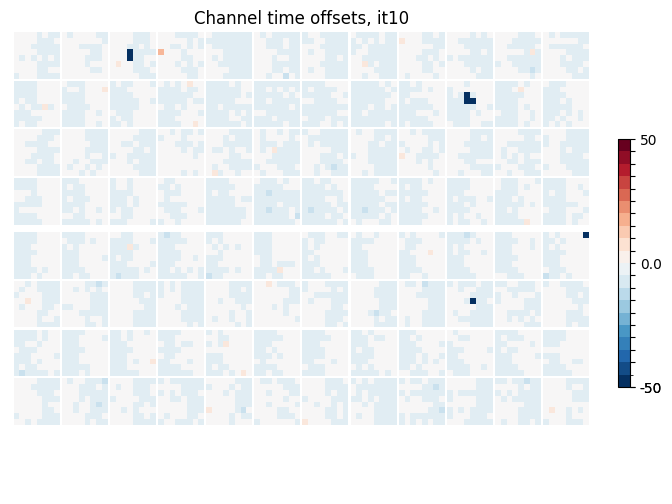

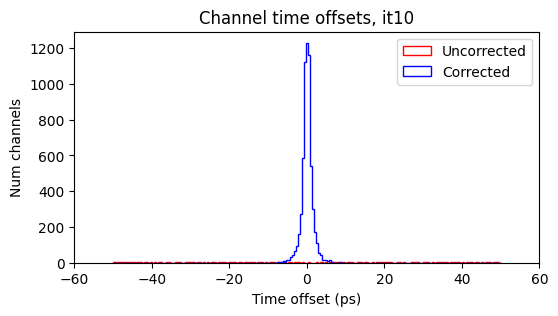

In [26]:
# Channel heatmapper
iterations = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
timerange = [1250, 1250, 500, 500, 500, 100, 100, 100, 100, 50, 50]
path = '/home/kale-chen/Documents/PET/TPPT2026/data/'
toffsets0 = np.fromfile(os.path.join(path, 'tsvs',f'it1toffsets.bin'), dtype=np.float32)
makeheatmap(toffsets0, f'Channel time offsets, it0', f'it0toffsets', -1250, 1250)
plt.figure(0, figsize = (6, 3))
bins = np.linspace(heatmapmin, heatmapmax, 200)
hist, bins = plt.hist(toffsets0, bins = bins, color = 'red', label = 'Uncorrected', histtype = 'step', linewidth = 1)[0:2]
plt.xlim(heatmapmin - 10, heatmapmax + 10)
plt.xlabel('Time offset (ps)')
plt.ylabel('Num channels')
plt.title('Channel time offsets, it0')
plt.legend()
plt.savefig(os.path.join(savedir, f'it0toffsetshist.pdf'), format='pdf', dpi=300, bbox_inches='tight')
plt.show()
for it in iterations[1:]:
    toffsets = np.fromfile(os.path.join(path, 'tsvs',f'it{str(it)}toffsets.bin'), dtype=np.float32)
    makeheatmap(toffsets, f'Channel time offsets, it{it - 1}', f'it{str(it - 1)}toffsets', -timerange[it-1], timerange[it-1])
    makehist(toffsets0, toffsets, f'Channel time offsets, it{it - 1}', f'it{str(it - 1)}toffsets', False, -timerange[it-1], timerange[it-1])

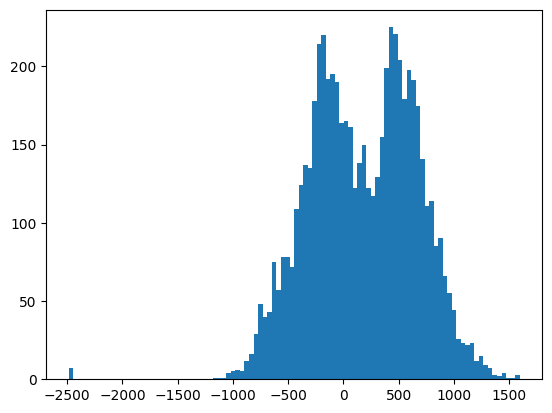

In [9]:
plt.hist(toffsets, bins = 100)
plt.show()

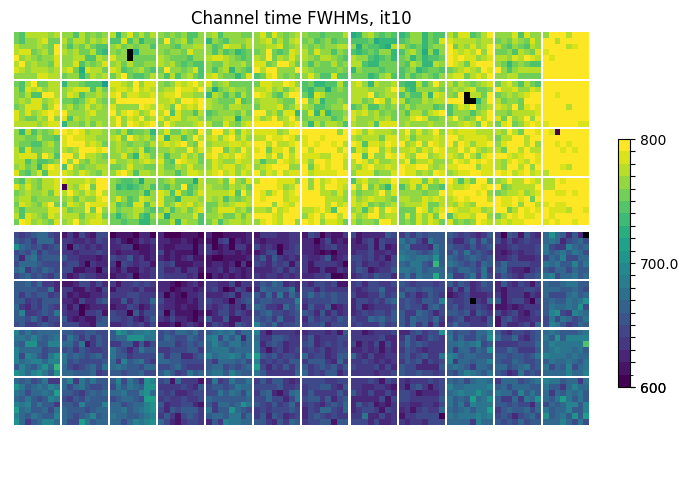

In [9]:
path = '/home/kale-chen/Documents/PET/TPPT2026/data/'
tspreads = np.fromfile(os.path.join(path, 'tsvs',f'it1tspreads.bin'), dtype=np.float32)
tspreads = np.abs(tspreads * 2.355)
tspreads[tspreads > 1000] = -1

cmap = plt.get_cmap('viridis') # 'seismic' or 'RdBu' or 'rwb'
makeheatmap(tspreads, f'Channel time FWHMs, it10', f'it0tspreads', 600, 800)

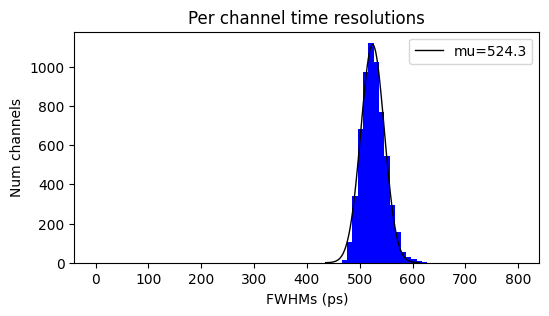

In [4]:
def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))
plt.figure(0, figsize = (6, 3))
hist, bins = plt.hist(tspreads, bins = np.linspace(0, 800, 80), color = 'blue')[0:2]
bincenters = (bins[1:] + bins[:-1]) / 2
popt, _ = curve_fit(gaussian, bincenters, hist, p0 = [1000, 510, 50])
plotting_bounds = np.linspace(popt[1] - 4 * popt[2], popt[1] + 4 * popt[2], 100)
plt.plot(plotting_bounds, gaussian(plotting_bounds, *popt), color = 'black', linewidth = 1, label = f'mu={round(popt[1],1)}')
plt.legend()
plt.xlabel('FWHMs (ps)')
plt.ylabel('Num channels')
plt.title('Per channel time resolutions')
plt.show()

In [37]:
acceptedchannels = tspreads[tspreads < 220]
acceptedchannels.tofile(os.path.join(path, 'tsvs',f'it10acceptedchannels.bin'))